# Pairformer Size Ablation

Compares pairformer variants at different scales on 5 representative ADMET tasks (scratch, no pre-training).

| Variant | Hidden Dim | Depth | Approx. Params |
|---|---|---|---|
| pairformer (base) | 96 | 16 | ~5M |
| pairformer_small | 192 | 8 | ~15M |
| pairformer_medium | 256 | 12 | ~40M |
| pairformer_large | 384 | 16 | ~100M |
| pairformer_boltz | 384 | 48 | 155M |

Additionally shows pairformer_boltz with pre-training (rxrx3, toymix) for reference.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

df = pd.read_csv('../results/experiment_results.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
print(f'Loaded {len(df)} rows')

Loaded 956 rows


In [7]:
# Task definitions (same 5 representative tasks)
TASKS = {
    'caco2_wang':        ('graph_caco2_wang/mae/test', 'lower', 'Absorption', 'MAE'),
    'pgp_broccatelli':   ('graph_pgp_broccatelli/auroc/test', 'higher', 'Absorption', 'AUROC'),
    'solubility_aqsoldb':('graph_solubility_aqsoldb/mae/test', 'lower', 'Absorption', 'MAE'),
    'half_life_obach':   ('graph_half_life_obach/spearman/test', 'higher', 'Excretion', 'Spearman'),
    'herg':              ('graph_herg/auroc/test', 'higher', 'Toxicity', 'AUROC'),
}
TASK_ORDER = list(TASKS.keys())

TDC_SOTA = {
    'caco2_wang':        (0.256, 0.006),
    'pgp_broccatelli':   (0.938, 0.002),
    'solubility_aqsoldb':(0.741, 0.013),
    'half_life_obach':   (0.576, 0.025),
    'herg':              (0.880, 0.002),
}

# Model variants ordered by size
MODEL_VARIANTS = [
    ('pairformer',        96,  16, '#64B478'),
    ('pairformer_small', 192,   8, '#466eff'),
    ('pairformer_medium',256,  12, '#FF883D'),
    ('pairformer_large', 384,  16, '#EB423D'),
    ('pairformer_boltz', 384,  48, '#9B59B6'),
]

def classify_model(row):
    tags = str(row.get('wandb_tags', ''))
    for name, _, _, _ in MODEL_VARIANTS:
        if name in tags:
            return name
    dim, depth = int(row.get('hidden_dim', 0)), int(row.get('gnn_depth', 0))
    if dim == 96 and depth == 16:
        return 'pairformer'
    return None

In [8]:
# Filter to pairformer rows
pf = df[df['model'] == 'pyg:pairformer'].copy()
pf['variant'] = pf.apply(classify_model, axis=1)
pf = pf[pf['variant'].notna()]
pf['is_ft'] = pf['is_finetuning'].fillna(False).astype(bool)

# Scratch runs only for the size ablation
scratch = pf[~pf['is_ft']].copy()
# Keep latest per (variant, task)
scratch = scratch.sort_values('timestamp').drop_duplicates(
    subset=['variant', 'task'], keep='last'
).reset_index(drop=True)

# FT runs for pairformer_boltz (for reference)
boltz_ft = pf[(pf['variant'] == 'pairformer_boltz') & pf['is_ft']].copy()
boltz_ft = boltz_ft.sort_values('timestamp').drop_duplicates(
    subset=['task'], keep='last'
).reset_index(drop=True)

print(f'Scratch rows: {len(scratch)}')
for v, _, _, _ in MODEL_VARIANTS:
    n = len(scratch[scratch['variant'] == v])
    print(f'  {v}: {n} tasks')
print(f'Boltz FT rows: {len(boltz_ft)}')

Scratch rows: 23
  pairformer: 23 tasks
  pairformer_small: 0 tasks
  pairformer_medium: 0 tasks
  pairformer_large: 0 tasks
  pairformer_boltz: 0 tasks
Boltz FT rows: 0


## 1. Results Table

In [9]:
def get_val(subset, task, col, variant=None):
    if variant is not None:
        rows = subset[subset['variant'] == variant]
    else:
        rows = subset
    rows = rows[rows['task'] == task]
    vals = pd.to_numeric(rows[col], errors='coerce').dropna()
    return vals.iloc[-1] if len(vals) > 0 else np.nan

# Build table
table_rows = []
for task in TASK_ORDER:
    col, direction, category, metric_name = TASKS[task]
    arrow = '\u2191' if direction == 'higher' else '\u2193'
    sota_mean, sota_std = TDC_SOTA[task]

    row = {
        'Task': task,
        'Category': category,
        f'Metric': f'{metric_name} {arrow}',
        'TDC SOTA': f'{sota_mean:.3f} \u00b1 {sota_std:.3f}',
    }
    for name, dim, depth, _ in MODEL_VARIANTS:
        row[f'{name}\n({dim}d/{depth}L)'] = get_val(scratch, task, col, variant=name)

    # Boltz FT
    row['boltz FT\n(rxrx3)'] = get_val(boltz_ft, task, col)

    table_rows.append(row)

results = pd.DataFrame(table_rows).set_index('Task')

# Find best scratch variant per task
scratch_cols = [f'{n}\n({d}d/{dp}L)' for n, d, dp, _ in MODEL_VARIANTS]

def highlight_best_scratch(row):
    task = row.name
    _, direction, _, _ = TASKS[task]
    styles = [''] * len(row)
    cols = list(results.columns)

    # Find best among scratch variants
    scratch_vals = {c: row[c] for c in scratch_cols if c in cols and pd.notna(row[c])}
    if scratch_vals:
        if direction == 'lower':
            best = min(scratch_vals, key=scratch_vals.get)
        else:
            best = max(scratch_vals, key=scratch_vals.get)
        j = cols.index(best)
        styles[j] = 'font-weight: bold; color: #1a5fb4'

    return styles

def sota_style(col):
    if col.name == 'TDC SOTA':
        return ['background-color: #f0f0f0; color: #555; font-size: 0.9em'] * len(col)
    return [''] * len(col)

fmt_cols = [c for c in results.columns if c not in ('Category', 'Metric', 'TDC SOTA')]
styled = (
    results.style
    .format(precision=4, na_rep='', subset=fmt_cols)
    .apply(highlight_best_scratch, axis=1)
    .apply(sota_style, axis=0)
    .set_caption('Pairformer Size Ablation — Scratch (no pre-training)')
    .set_table_styles([
        {'selector': 'th', 'props': [('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('text-align', 'center')]},
    ])
)
print('Blue = best among scratch variants')
display(styled)

Blue = best among scratch variants


,Category,Metric,TDC SOTA,pairformer (96d/16L),pairformer_small (192d/8L),pairformer_medium (256d/12L),pairformer_large (384d/16L),pairformer_boltz (384d/48L),boltz FT (rxrx3)
Task,,,,,,,,,
caco2_wang,Absorption,MAE ↓,0.256 ± 0.006,1.2734,,,,,
pgp_broccatelli,Absorption,AUROC ↑,0.938 ± 0.002,0.8632,,,,,
solubility_aqsoldb,Absorption,MAE ↓,0.741 ± 0.013,0.8906,,,,,
half_life_obach,Excretion,Spearman ↑,0.576 ± 0.025,0.0613,,,,,
herg,Toxicity,AUROC ↑,0.880 ± 0.002,0.7784,,,,,


## 2. Per-task bar chart

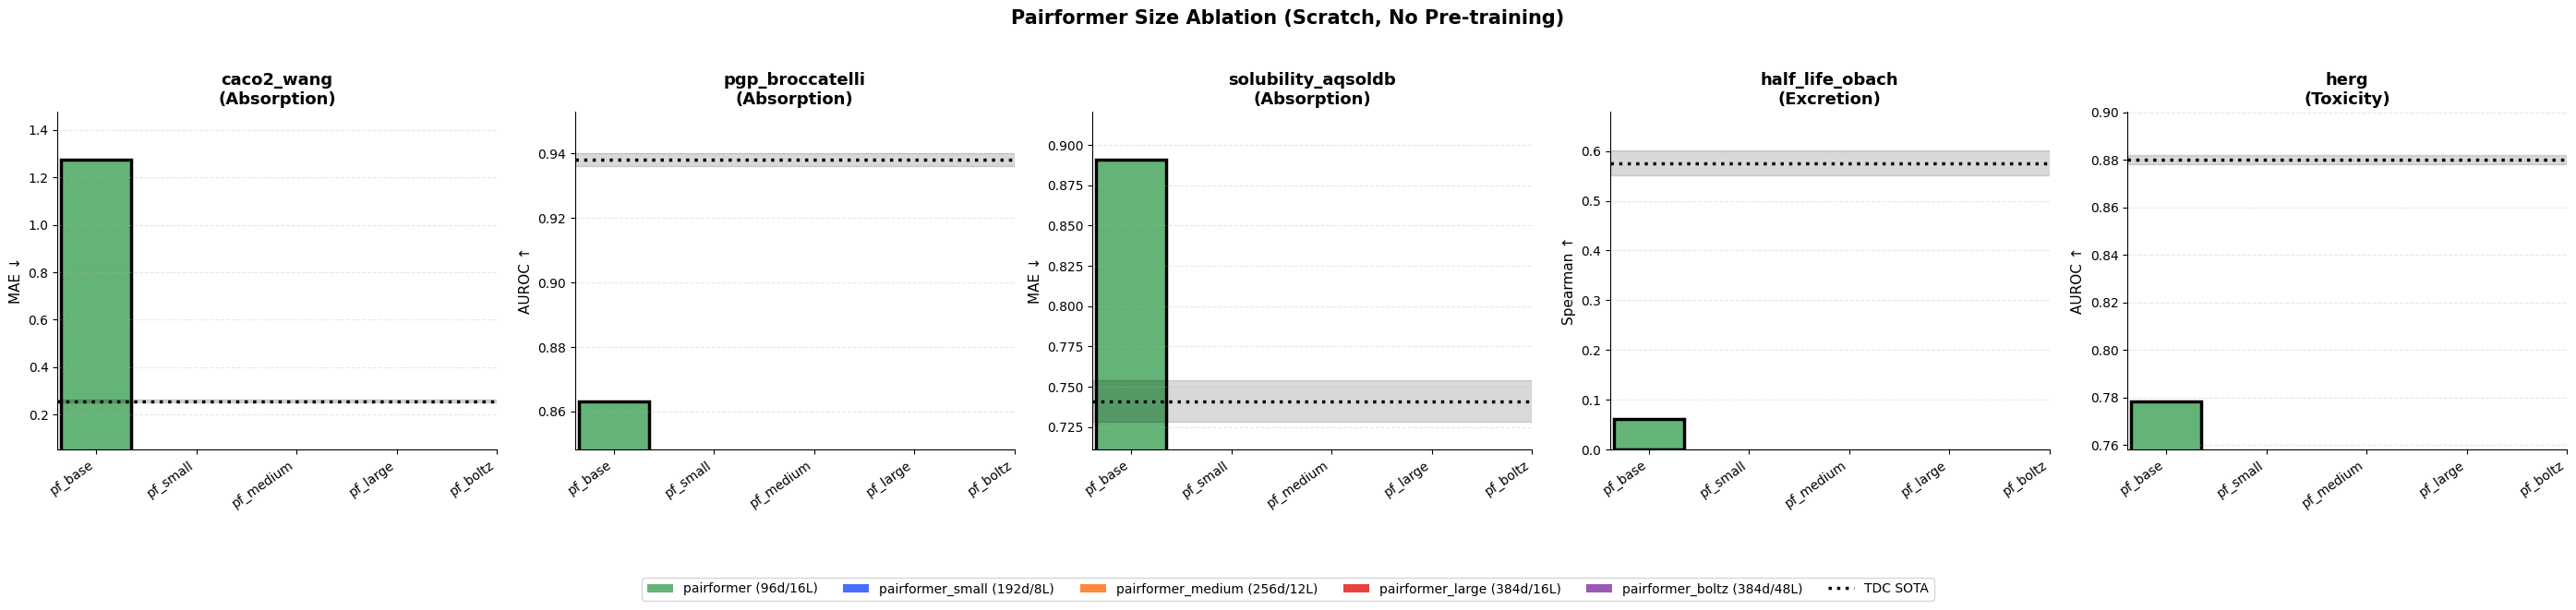

In [10]:
fig, axes = plt.subplots(1, len(TASK_ORDER), figsize=(28, 6))

bar_labels = [f'{n}\n({d}d/{dp}L)' for n, d, dp, _ in MODEL_VARIANTS]
bar_colors = [c for _, _, _, c in MODEL_VARIANTS]
n_bars = len(MODEL_VARIANTS)

for ax, task in zip(axes, TASK_ORDER):
    col, direction, category, metric_name = TASKS[task]
    arrow = '\u2191' if direction == 'higher' else '\u2193'
    sota_mean, sota_std = TDC_SOTA[task]

    vals = []
    for name, _, _, _ in MODEL_VARIANTS:
        vals.append(get_val(scratch, task, col, variant=name))

    # Find best scratch
    finite = [(i, v) for i, v in enumerate(vals) if pd.notna(v)]
    best_idx = None
    if finite:
        if direction == 'lower':
            best_idx = min(finite, key=lambda x: x[1])[0]
        else:
            best_idx = max(finite, key=lambda x: x[1])[0]

    for i, (v, c) in enumerate(zip(vals, bar_colors)):
        if pd.notna(v):
            ec = 'black' if i == best_idx else c
            lw = 2.5 if i == best_idx else 0.5
            ax.bar(i, v, color=c, edgecolor=ec, linewidth=lw, width=0.7)

    # SOTA line
    ax.axhline(y=sota_mean, color='black', linewidth=2.5, linestyle=':', zorder=5)
    ax.axhspan(sota_mean - sota_std, sota_mean + sota_std,
               alpha=0.15, color='black', zorder=1)

    # Y-axis limits
    all_v = [v for v in vals if pd.notna(v)] + [sota_mean]
    if all_v:
        vmin, vmax = min(all_v), max(all_v)
        span = vmax - vmin if vmax > vmin else vmax * 0.1
        ax.set_ylim(max(0, vmin - span * 0.2), vmax + span * 0.2)

    short = [n.replace('pairformer_', 'pf_').replace('pairformer', 'pf_base')
             for n, _, _, _ in MODEL_VARIANTS]
    ax.set_xticks(range(n_bars))
    ax.set_xticklabels(short, rotation=35, ha='right', fontsize=10)
    ax.set_title(f'{task}\n({category})', fontsize=13, fontweight='bold')
    ax.set_ylabel(f'{metric_name} {arrow}', fontsize=11)
    ax.tick_params(axis='y', labelsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, axis='y', ls='--', alpha=0.3)

# Legend
legend_handles = [Patch(facecolor=c, label=f'{n} ({d}d/{dp}L)')
                  for n, d, dp, c in MODEL_VARIANTS]
legend_handles.append(Line2D([0], [0], color='black', linewidth=2.5, linestyle=':', label='TDC SOTA'))
fig.legend(handles=legend_handles, loc='lower center', ncol=len(legend_handles),
           fontsize=10, bbox_to_anchor=(0.5, -0.1), frameon=True)

fig.suptitle('Pairformer Size Ablation (Scratch, No Pre-training)',
             fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

## 3. Scaling trend: performance vs model size

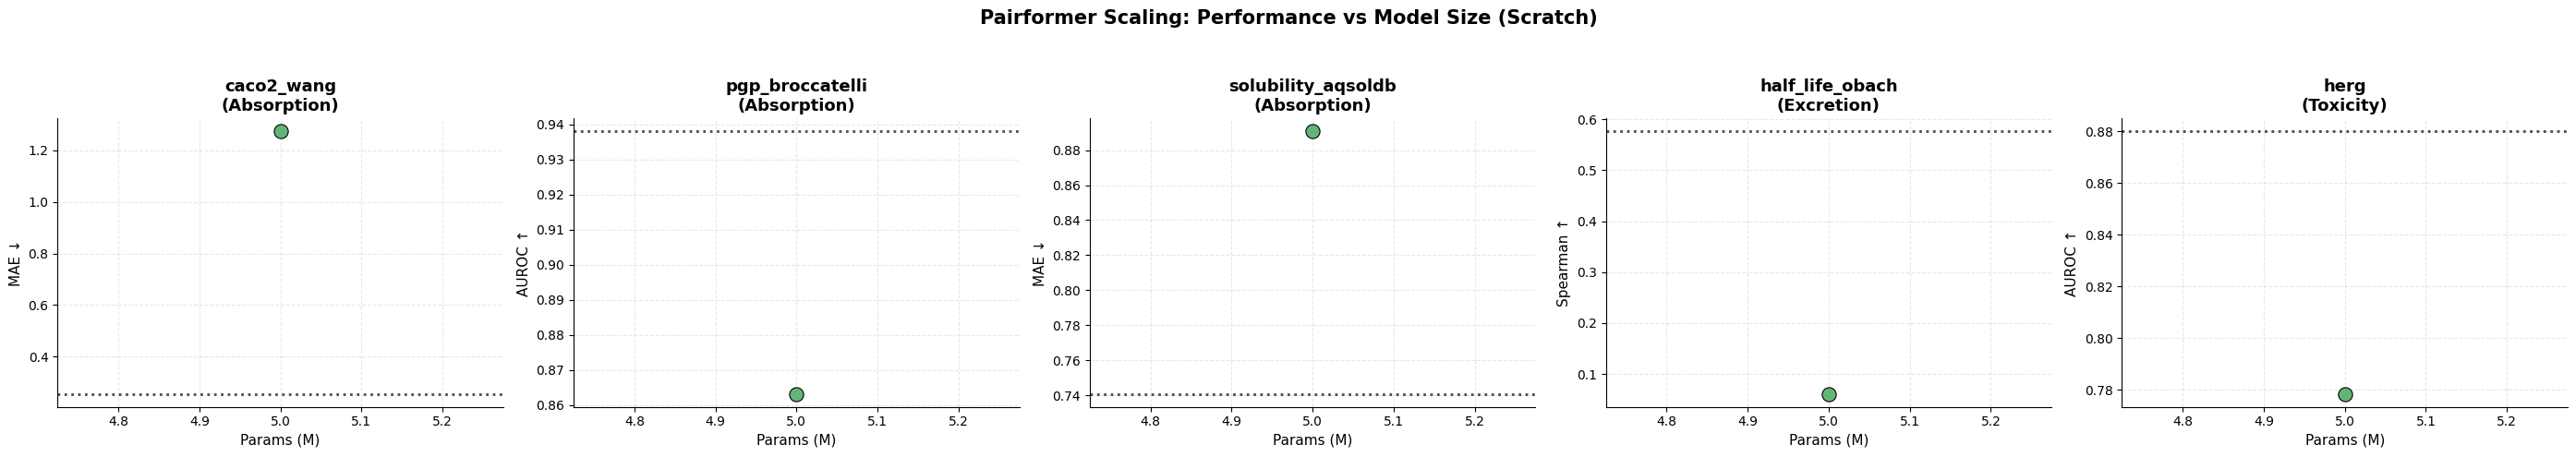

In [11]:
# Approximate parameter counts (from config analysis)
PARAM_COUNTS = {
    'pairformer': 5,
    'pairformer_small': 15,
    'pairformer_medium': 40,
    'pairformer_large': 100,
    'pairformer_boltz': 155,
}

fig, axes = plt.subplots(1, len(TASK_ORDER), figsize=(28, 5))

for ax, task in zip(axes, TASK_ORDER):
    col, direction, category, metric_name = TASKS[task]
    arrow = '\u2191' if direction == 'higher' else '\u2193'
    sota_mean, sota_std = TDC_SOTA[task]

    xs, ys, colors = [], [], []
    for name, dim, depth, color in MODEL_VARIANTS:
        v = get_val(scratch, task, col, variant=name)
        if pd.notna(v):
            xs.append(PARAM_COUNTS[name])
            ys.append(v)
            colors.append(color)

    ax.scatter(xs, ys, c=colors, s=120, zorder=5, edgecolors='black', linewidth=0.8)

    # Connect with line
    if len(xs) > 1:
        order = np.argsort(xs)
        ax.plot([xs[i] for i in order], [ys[i] for i in order],
                color='grey', linewidth=1, linestyle='--', alpha=0.5, zorder=1)

    # SOTA line
    ax.axhline(y=sota_mean, color='black', linewidth=2, linestyle=':', alpha=0.7)

    ax.set_xlabel('Params (M)', fontsize=11)
    ax.set_ylabel(f'{metric_name} {arrow}', fontsize=11)
    ax.set_title(f'{task}\n({category})', fontsize=13, fontweight='bold')
    ax.tick_params(labelsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, ls='--', alpha=0.3)

fig.suptitle('Pairformer Scaling: Performance vs Model Size (Scratch)',
             fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## 4. Effect of pre-training on pairformer_boltz

Conditions: ['Scratch']


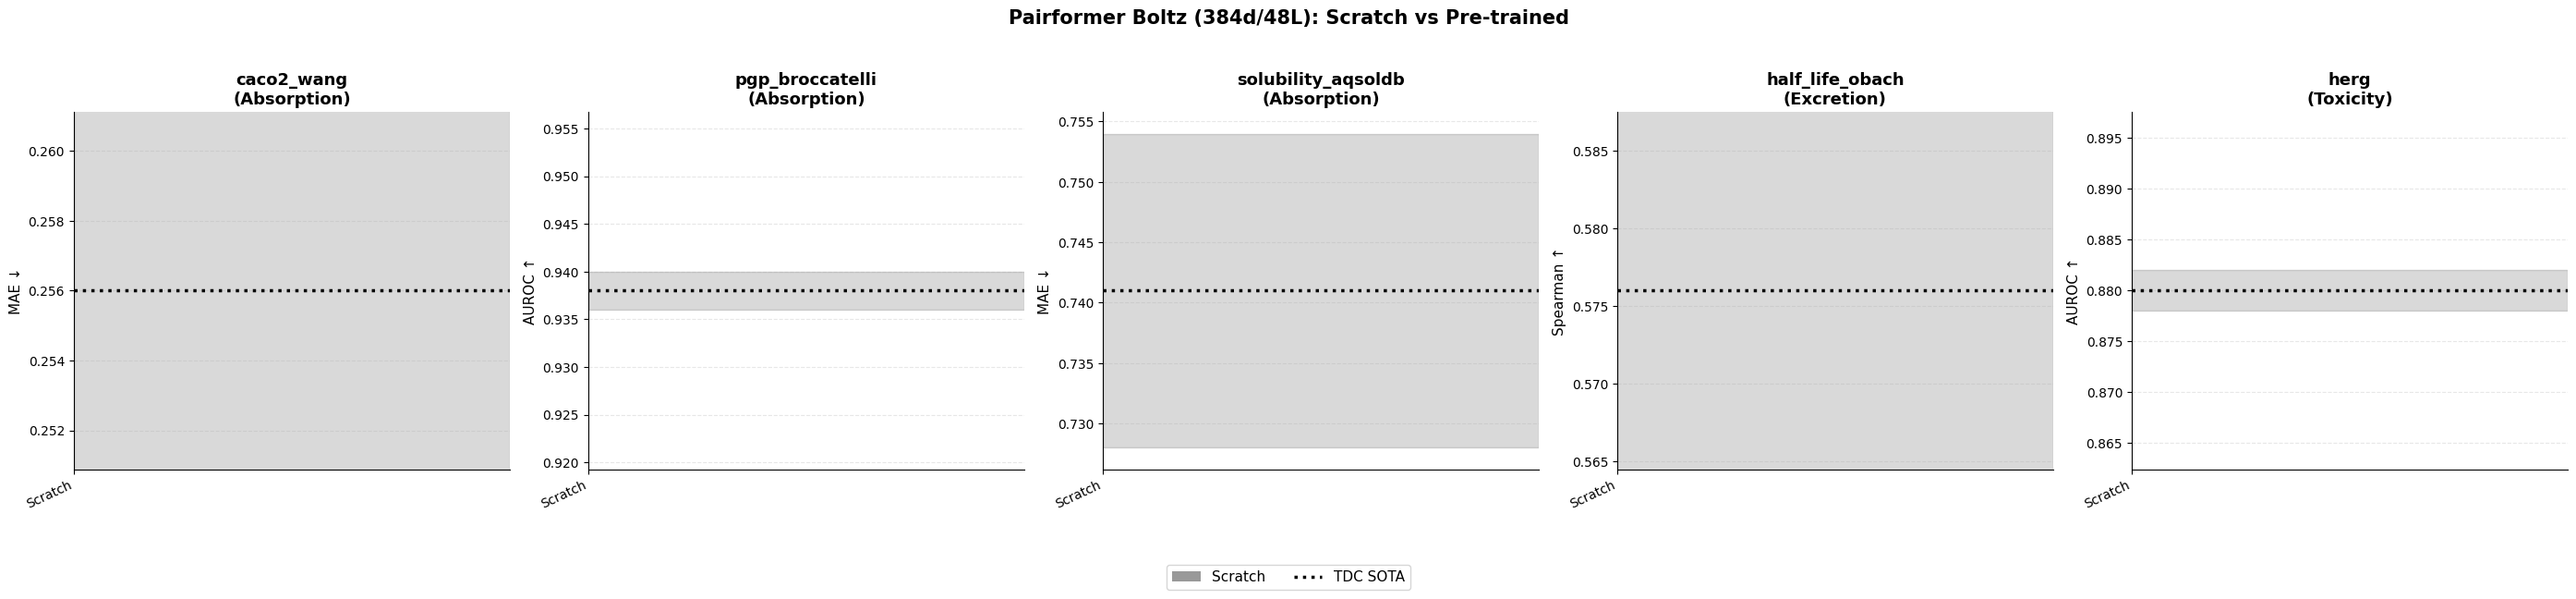

In [12]:
# Compare pairformer_boltz: scratch vs FT (rxrx3) vs FT (toymix)
boltz_scratch = scratch[scratch['variant'] == 'pairformer_boltz']

# Separate FT by pretrain dataset
pf_ft_all = pf[(pf['variant'] == 'pairformer_boltz') & pf['is_ft']].copy()
pf_ft_all['pt_type'] = pf_ft_all['pretrain_dataset'].apply(
    lambda s: 'rxrx3' if 'rxrx3' in str(s).lower() else
              ('toymix' if 'toymix' in str(s).lower() else 'other')
)

conditions = [
    ('Scratch', boltz_scratch, '#999999'),
]
for pt_type, color in [('toymix', '#466eff'), ('rxrx3', '#64B478')]:
    sub = pf_ft_all[pf_ft_all['pt_type'] == pt_type]
    if len(sub) > 0:
        conditions.append((f'FT ({pt_type})', sub, color))

print(f'Conditions: {[c[0] for c in conditions]}')

fig, axes = plt.subplots(1, len(TASK_ORDER), figsize=(28, 6))
n_cond = len(conditions)

for ax, task in zip(axes, TASK_ORDER):
    col, direction, category, metric_name = TASKS[task]
    arrow = '\u2191' if direction == 'higher' else '\u2193'
    sota_mean, sota_std = TDC_SOTA[task]

    vals = []
    for label, sub, color in conditions:
        v = pd.to_numeric(sub[sub['task'] == task][col], errors='coerce').dropna()
        vals.append(v.iloc[-1] if len(v) > 0 else np.nan)

    # Find best
    finite = [(i, v) for i, v in enumerate(vals) if pd.notna(v)]
    best_idx = None
    if finite:
        best_idx = (min if direction == 'lower' else max)(finite, key=lambda x: x[1])[0]

    for i, (v, (label, _, color)) in enumerate(zip(vals, conditions)):
        if pd.notna(v):
            ec = 'black' if i == best_idx else color
            lw = 2.5 if i == best_idx else 0.5
            ax.bar(i, v, color=color, edgecolor=ec, linewidth=lw, width=0.6)

    ax.axhline(y=sota_mean, color='black', linewidth=2.5, linestyle=':', zorder=5)
    ax.axhspan(sota_mean - sota_std, sota_mean + sota_std,
               alpha=0.15, color='black', zorder=1)

    all_v = [v for v in vals if pd.notna(v)] + [sota_mean]
    if all_v:
        vmin, vmax = min(all_v), max(all_v)
        span = vmax - vmin if vmax > vmin else vmax * 0.1
        ax.set_ylim(max(0, vmin - span * 0.2), vmax + span * 0.2)

    ax.set_xticks(range(n_cond))
    ax.set_xticklabels([c[0] for c in conditions], rotation=25, ha='right', fontsize=10)
    ax.set_title(f'{task}\n({category})', fontsize=13, fontweight='bold')
    ax.set_ylabel(f'{metric_name} {arrow}', fontsize=11)
    ax.tick_params(axis='y', labelsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, axis='y', ls='--', alpha=0.3)

legend_handles = [Patch(facecolor=c, label=l) for l, _, c in conditions]
legend_handles.append(Line2D([0], [0], color='black', linewidth=2.5, linestyle=':', label='TDC SOTA'))
fig.legend(handles=legend_handles, loc='lower center', ncol=len(legend_handles),
           fontsize=11, bbox_to_anchor=(0.5, -0.08), frameon=True)

fig.suptitle('Pairformer Boltz (384d/48L): Scratch vs Pre-trained',
             fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

## 5. Training time comparison

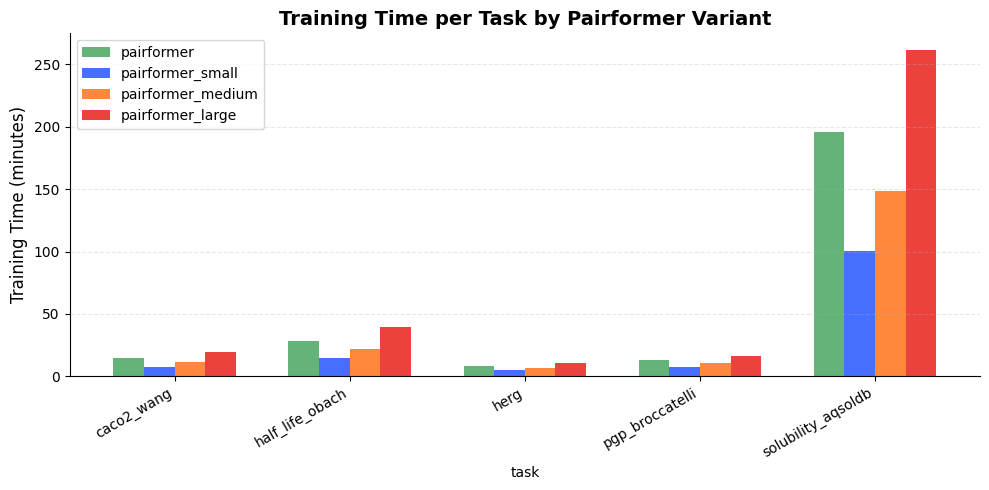

In [13]:
# Load from the benchmark TSV (has timing data)
from pathlib import Path
tsv_path = Path('../results/pairformer_size_benchmark.tsv')
if tsv_path.exists():
    bench = pd.read_csv(tsv_path, sep='\t')
    bench['time_min'] = pd.to_numeric(bench['time_s'], errors='coerce') / 60

    # Pivot: model x task
    time_pivot = bench.pivot_table(index='model', columns='task', values='time_min')

    model_order = ['pairformer', 'pairformer_small', 'pairformer_medium', 'pairformer_large']
    model_order = [m for m in model_order if m in time_pivot.index]
    time_pivot = time_pivot.loc[model_order]

    fig, ax = plt.subplots(figsize=(10, 5))
    time_pivot.T.plot(kind='bar', ax=ax, width=0.7,
                      color=[c for n, _, _, c in MODEL_VARIANTS if n in model_order])
    ax.set_ylabel('Training Time (minutes)', fontsize=12)
    ax.set_title('Training Time per Task by Pairformer Variant', fontsize=14, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, axis='y', ls='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f'Benchmark TSV not found at {tsv_path}')